# Impact of Recommender Algorithms on User Retention: A Comparative Analysis

## TFG - Daniel Morán Lordén


## Case Study - Comparative Analysis of Different Recommender Algorithms Using MovieLens 100k Dataset

### Data loading and EDA

In [12]:
!pip install --upgrade pip setuptools wheel Cython
!pip install pandas==1.5.3 matplotlib seaborn
!pip install numpy==1.26.4
!pip install scikit-surprise==1.1.4
import pandas as pd
from surprise import Dataset

data = Dataset.load_builtin('ml-100k')

raw_ratings = data.raw_ratings
df = pd.DataFrame(raw_ratings, columns=['User_ID', 'Movie_ID', 'Rating', 'Timestamp'])

stats = {
    "Total ratings": len(df),
    "Unique users": df['User_ID'].nunique(),
    "Unique movies": df['Movie_ID'].nunique(),
    "Average score": round(df['Rating'].mean(), 2)
}

for key, value in stats.items():
    print(f"{key}: {value}")

print("\nFirst 5 rows:")
print(df.head())

  Using cached pandas-1.5.3.tar.gz (5.2 MB)
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> No available output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
ERROR: Failed to build 'pandas' when getting requirements to build wheel
Total ratings: 100000
Unique users: 943
Unique movies: 1682
Average score: 3.53

First 5 rows:
  User_ID Movie_ID  Rating  Timestamp
0     196      242     3.0  881250949
1     186      302     3.0  891717742
2      22      377     1.0  878887116
3     244       51     2.0  880606923
4     166      346     1.0  886397596


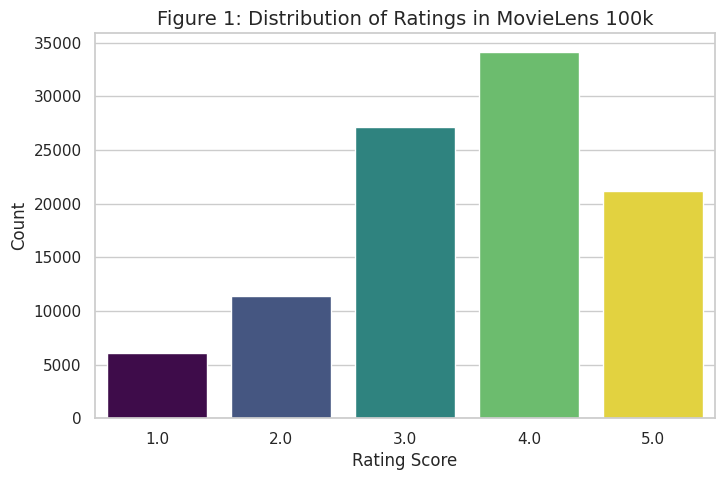

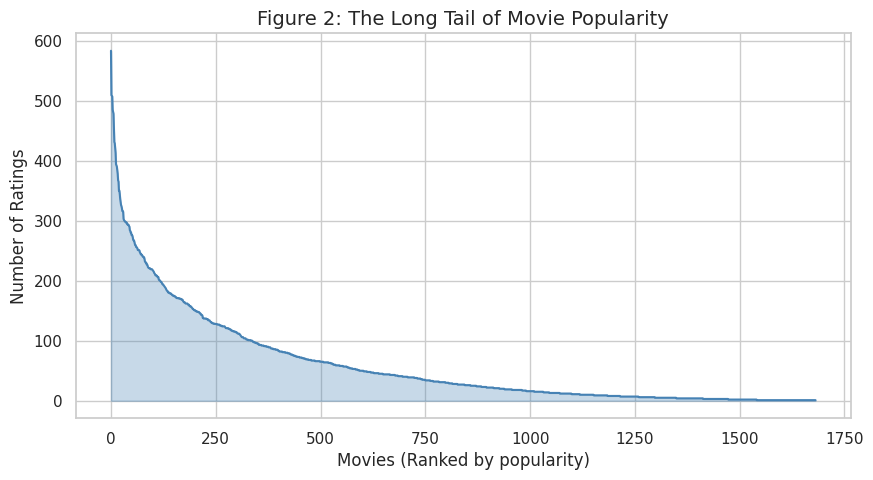

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 5))
sns.countplot(x='Rating', data=df, hue='Rating', palette='viridis', legend=False)
plt.title('Figure 1: Distribution of Ratings in MovieLens 100k', fontsize=14)
plt.xlabel('Rating Score')
plt.ylabel('Count')
plt.show()

movie_counts = df['Movie_ID'].value_counts()
plt.figure(figsize=(10, 5))
plt.plot(range(len(movie_counts)), movie_counts.values, color='steelblue')
plt.fill_between(range(len(movie_counts)), movie_counts.values, color='steelblue', alpha=0.3)
plt.title('Figure 2: The Long Tail of Movie Popularity', fontsize=14)
plt.xlabel('Movies (Ranked by popularity)')
plt.ylabel('Number of Ratings')
plt.show()

### Algorithms implementation

Preprocessing

In [14]:
from surprise.model_selection import train_test_split

trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

print(f"Total ratings in Training Set: {trainset.n_ratings}")
print(f"Total ratings in Test Set: {len(testset)}")

Total ratings in Training Set: 80000
Total ratings in Test Set: 20000


Implementation

In [20]:
import time
from surprise import NormalPredictor, KNNBasic, SVD
from surprise import accuracy

models = {
    "Popularity-based": NormalPredictor(),
    "KNN": KNNBasic(sim_options={'name': 'cosine', 'user_based': True}, verbose=False),
    "SVD": SVD(n_factors=50, random_state=42)
}

results_list = []
saved_predictions = {}

for name, algo in models.items():
    start_train = time.time()
    algo.fit(trainset)
    train_time = time.time() - start_train

    start_pred = time.time()
    predictions = algo.test(testset)
    test_time = time.time() - start_pred

    rmse = accuracy.rmse(predictions, verbose=False)
    mae = accuracy.mae(predictions, verbose=False)

    results_list.append({
        "Algorithm": name,
        "RMSE": round(rmse, 4),
        "MAE": round(mae, 4),
        "Fit Time (s)": round(train_time, 4),
        "Test Time (s)": round(test_time, 4)
    })
    saved_predictions[name] = predictions

results_df = pd.DataFrame(results_list)
print(results_df)

          Algorithm    RMSE     MAE  Fit Time (s)  Test Time (s)
0  Popularity-based  1.5136  1.2110        0.0573         0.0777
1               KNN  1.0194  0.8038        0.6095         2.7806
2               SVD  0.9348  0.7377        0.8627         0.1075


Visualizations

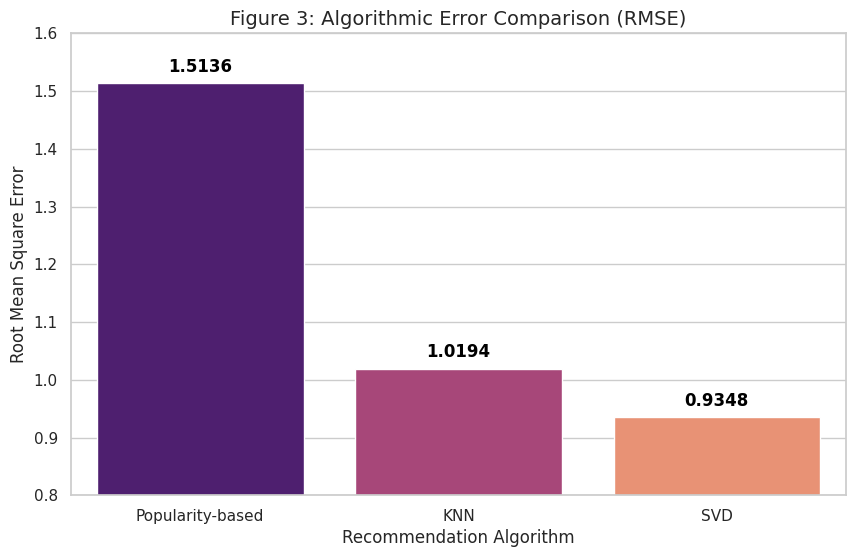

In [21]:
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Algorithm',
    y='RMSE',
    data=results_df,
    hue='Algorithm',
    palette='magma',
    legend=False
)

plt.title('Figure 3: Algorithmic Error Comparison (RMSE)', fontsize=14)
plt.ylabel('Root Mean Square Error')
plt.xlabel('Recommendation Algorithm')
plt.ylim(0.8, 1.6)

for index, row in results_df.iterrows():
    plt.text(index, row.RMSE + 0.02, round(row.RMSE, 4), color='black', ha="center", fontweight='bold')

plt.show()

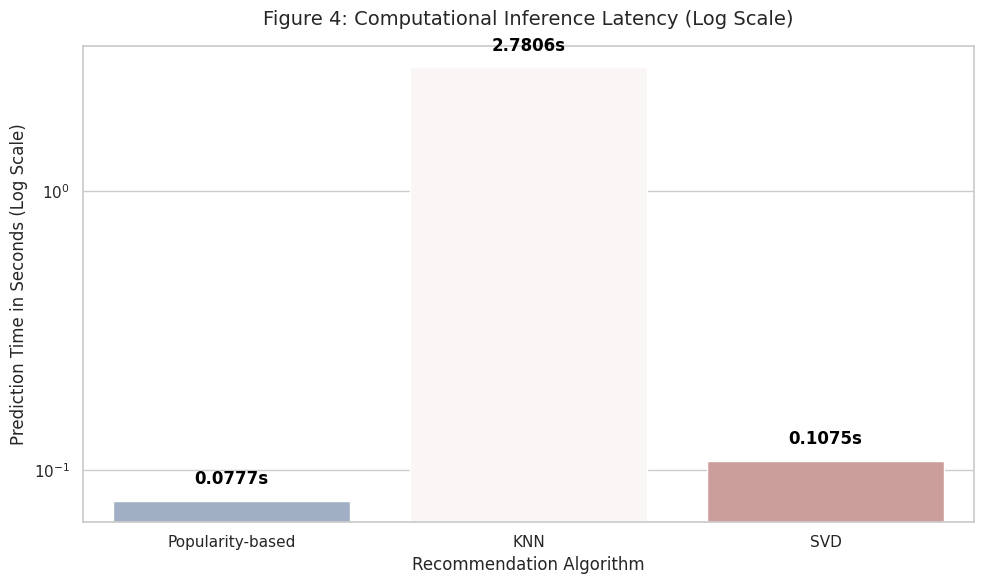

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x='Algorithm',
    y='Test Time (s)',
    data=results_df,
    hue='Algorithm',
    palette='vlag',
    legend=False
)

plt.yscale('log')

plt.title('Figure 4: Computational Inference Latency (Log Scale)', fontsize=14, pad=15)
plt.ylabel('Prediction Time in Seconds (Log Scale)')
plt.xlabel('Recommendation Algorithm')

for index, row in results_df.iterrows():
    ax.text(
        index,
        row['Test Time (s)'] * 1.15,
        f"{round(row['Test Time (s)'], 4)}s",
        color='black',
        ha="center",
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

Classification metrics

In [23]:
from collections import defaultdict
import numpy as np
import pandas as pd

def precision_recall_at_k(predictions, k=10, threshold=3.5):
    user_est_true = defaultdict(list)
    for uid, _, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))

    precisions = dict()
    recalls = dict()

    for uid, user_ratings in user_est_true.items():
        user_ratings.sort(key=lambda x: x[0], reverse=True)

        n_rel = sum((true_r >= threshold) for (_, true_r) in user_ratings)

        n_rec_k = sum((est >= threshold) for (est, _) in user_ratings[:k])

        n_rel_and_rec_k = sum(((true_r >= threshold) and (est >= threshold)) for (est, true_r) in user_ratings[:k])

        precisions[uid] = n_rel_and_rec_k / n_rec_k if n_rec_k != 0 else 0

        recalls[uid] = n_rel_and_rec_k / n_rel if n_rel != 0 else 0

    return np.mean(list(precisions.values())), np.mean(list(recalls.values()))


classification_results = []

for name, preds in saved_predictions.items():
    prec, rec = precision_recall_at_k(preds, k=10, threshold=3.5)
    classification_results.append({
        "Algorithm": name,
        "Precision@10": round(prec, 4),
        "Recall@10": round(rec, 4)
    })

classification_df = pd.DataFrame(classification_results)

print(classification_df.to_string(index=False))

       Algorithm  Precision@10  Recall@10
Popularity-based        0.5793     0.4267
             KNN        0.7184     0.5878
             SVD        0.7135     0.5454


Cold-start test

In [24]:
import numpy as np
import pandas as pd
from surprise import accuracy

user_activity_counts = df['User_ID'].value_counts()


for name, preds in saved_predictions.items():

    cold_user_preds = []
    heavy_user_preds = []

    for pred in preds:
        raw_uid = pred.uid
        activity = user_activity_counts.get(raw_uid, 0)

        if activity <= 20:
            cold_user_preds.append(pred)
        elif activity >= 150:
            heavy_user_preds.append(pred)

    print(f"\n{name}")
    print(f"  -> Cold Users Sample Size: {len(cold_user_preds)}")
    if len(cold_user_preds) > 0:
        cold_rmse = accuracy.rmse(cold_user_preds, verbose=False)
        print(f"  -> RMSE on Cold Users (<= 20): {round(cold_rmse, 4)}")
    print(f"  -> Heavy Users Sample Size: {len(heavy_user_preds)}")
    if len(heavy_user_preds) > 0:
        heavy_rmse = accuracy.rmse(heavy_user_preds, verbose=False)
        print(f"  -> RMSE on Heavy Users (>= 150): {round(heavy_rmse, 4)}")


Popularity-based
  -> Cold Users Sample Size: 131
  -> RMSE on Cold Users (<= 20): 1.5029
  -> Heavy Users Sample Size: 11600
  -> RMSE on Heavy Users (>= 150): 1.5185

KNN
  -> Cold Users Sample Size: 131
  -> RMSE on Cold Users (<= 20): 1.1948
  -> Heavy Users Sample Size: 11600
  -> RMSE on Heavy Users (>= 150): 1.0126

SVD
  -> Cold Users Sample Size: 131
  -> RMSE on Cold Users (<= 20): 1.0644
  -> Heavy Users Sample Size: 11600
  -> RMSE on Heavy Users (>= 150): 0.9208
